Name: **Anay Abhijit Joshi**

In [ ]:
# Installing package
if (!require(readxl)) install.packages("readxl", repos = "https://cloud.r-project.org")
library(readxl)

# Reading the worksheet specified in the homework (uploaded in the Files in Google Colab)
baseball <- read_excel("hw5-s26-baseball-all-data.xlsx", sheet = "W-BA-ERA-SB")

# Keeping only the relevant columns and rename them clearly
baseball <- baseball[, c("Team", "W", "BA", "ERA", "SB")]
colnames(baseball) <- c("Team", "W", "BA", "ERA", "SB")

# Removing any blank rows (if present)
baseball <- na.omit(baseball)

# Quick sanity check
print(baseball)
str(baseball)
summary(baseball)
dim(baseball)

New names:
• `` -> `...2`


# A tibble: 30 × 5
   Team                     W    BA   ERA    SB
   <chr>                <dbl> <dbl> <dbl> <dbl>
 1 Arizona Diamondbacks    89 0.263  4.62   119
 2 Atlanta Braves          89 0.243  3.49    69
 3 Baltimore Orioles       91 0.25   3.94    98
 4 Boston Red Sox          81 0.252  4.04   144
 5 Chicago Cubs            83 0.242  3.78   143
 6 Chicago White Sox       41 0.221  4.68    90
 7 Cincinnati Reds         77 0.231  4.09   207
 8 Cleveland Guardians     92 0.238  3.61   148
 9 Colorado Rockies        61 0.242  5.47    85
10 Detroit Tigers          86 0.234  3.61    76
# ℹ 20 more rows
tibble [30 × 5] (S3: tbl_df/tbl/data.frame)
 $ Team: chr [1:30] "Arizona Diamondbacks" "Atlanta Braves" "Baltimore Orioles" "Boston Red Sox" ...
 $ W   : num [1:30] 89 89 91 81 83 41 77 92 61 86 ...
 $ BA  : num [1:30] 0.263 0.243 0.25 0.252 0.242 0.221 0.231 0.238 0.242 0.234 ...
 $ ERA : num [1:30] 4.62 3.49 3.94 4.04 3.78 4.68 4.09 3.61 5.47 3.61 ...
 $ SB  : num [1:30] 119 69 98 14

     Team                 W               BA              ERA       
 Length:30          Min.   :41.00   Min.   :0.2210   Min.   :3.490  
 Class :character   1st Qu.:76.25   1st Qu.:0.2350   1st Qu.:3.763  
 Mode  :character   Median :83.00   Median :0.2430   Median :3.995  
                    Mean   :80.97   Mean   :0.2432   Mean   :4.073  
                    3rd Qu.:89.00   3rd Qu.:0.2480   3rd Qu.:4.298  
                    Max.   :98.00   Max.   :0.2630   Max.   :5.470  
       SB        
 Min.   : 65.00  
 1st Qu.: 90.25  
 Median :112.50  
 Mean   :120.57  
 3rd Qu.:142.25  
 Max.   :223.00  

[1] 30  5

#**Question 3**

         W     BA    ERA     SB
W    1.000  0.616 -0.737  0.101
BA   0.616  1.000 -0.121 -0.033
ERA -0.737 -0.121  1.000 -0.179
SB   0.101 -0.033 -0.179  1.000


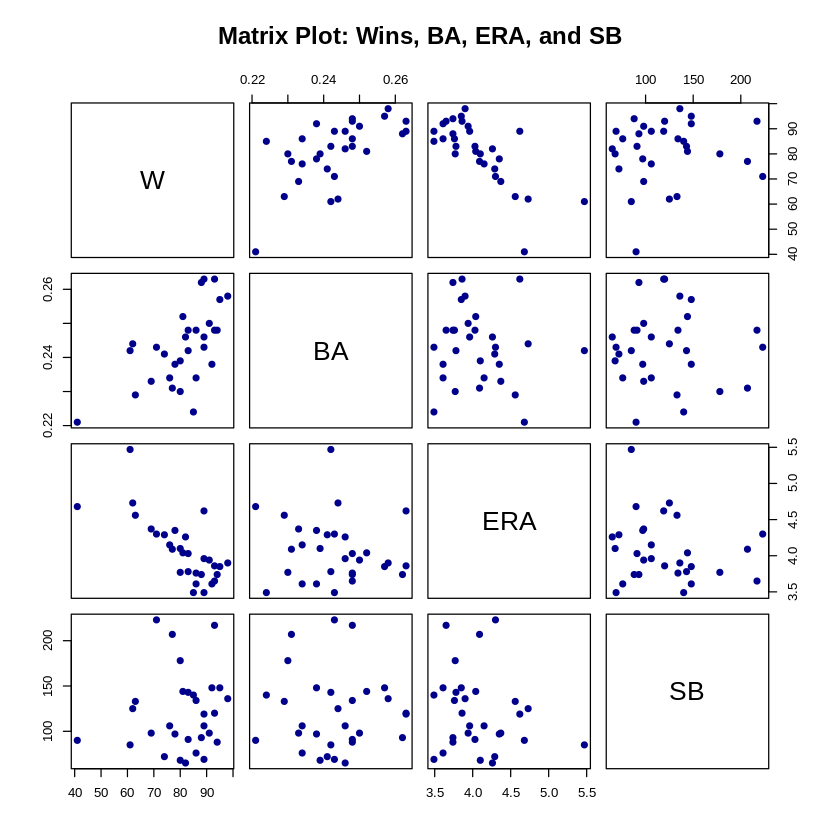

In [ ]:
# Question 3: Matrix plot and interpretation

# Using only numerical variables for the matrix plot
num_data <- baseball[, c("W", "BA", "ERA", "SB")]

# Correlation matrix
cor_matrix <- cor(num_data)
print(round(cor_matrix, 3))

# Matrix plot
pairs(
  num_data,
  main = "Matrix Plot: Wins, BA, ERA, and SB",
  pch = 19,
  col = "darkblue"
)

From the matrix plot and the correlation matrix, I examined the pairwise relationships among **Wins (W)**, **Batting Average (BA)**, **Earned Run Average (ERA)**, and **Stolen Bases (SB)** for the 2024 teams. In my observation, the strongest relationship with Wins appears to be **ERA**, which shows a **strong negative association** with a correlation of approximately **−0.737**. This indicates that teams with **lower ERA tend to win more games**, which is consistent with the idea that stronger pitching performance contributes significantly to team success. I also observe a **moderate positive relationship between Wins and BA** (correlation = **0.616**), suggesting that teams with higher batting averages generally tend to win more games, although the relationship is not perfectly linear. The relationship between **Wins and SB** appears to be **very weak**, with a small positive correlation of about **0.101**, indicating that stolen bases alone do not appear to strongly influence the number of wins.

Looking at the relationships among the predictor variables themselves, **BA and ERA show only a weak negative correlation** (= −0.121), suggesting that these variables are largely independent and do not show strong evidence of multicollinearity from the matrix plot. Similarly, **SB appears to have weak relationships with both BA and ERA**, with correlations of about −0.033 and −0.179 respectively. Overall, based on the matrix plot and correlation values, I observe that **Wins tends to increase with higher BA, decrease with higher ERA, and shows little clear relationship with SB**. The patterns between Wins and the main predictors (BA and ERA) appear reasonably **linear**, which suggests that a **multiple linear regression model using BA, ERA, and SB as predictors for Wins is a reasonable starting point for further analysis**...

#**Question 4**

In [ ]:
# Question 4
# y = beta0 + beta1*BA + beta2*ERA + beta3*SB + e

# Fitting the model
model1 <- lm(W ~ BA + ERA + SB, data = baseball)

# Here is the full regression output
summary(model1)

# ANOVA table
anova(model1)

# R-squared and adjusted R-squared
summary(model1)$r.squared
summary(model1)$adj.r.squared

# Coefficients only
coef(model1)

# Confidence intervals for coefficients (honestly, it's optional but definitely useful)
confint(model1)


Call:
lm(formula = W ~ BA + ERA + SB, data = baseball)

Residuals:
    Min      1Q  Median      3Q     Max 
-14.896  -3.037   1.303   3.756   7.553 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.194e+01  2.638e+01   0.453    0.654    
BA           6.058e+02  9.346e+01   6.482 7.19e-07 ***
ERA         -1.921e+01  2.393e+00  -8.025 1.67e-08 ***
SB          -5.349e-04  2.411e-02  -0.022    0.982    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.494 on 26 degrees of freedom
Multiple R-squared:  0.8259,	Adjusted R-squared:  0.8058 
F-statistic: 41.12 on 3 and 26 DF,  p-value: 5.162e-10


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
BA,1,1.713348e+03,1.713348e+03,5.675583e+01,5.352900e-08
ERA,1,2.010715e+03,2.010715e+03,6.660631e+01,1.214216e-08
SB,1,1.486154e-02,1.486154e-02,4.922988e-04,9.824676e-01
Residuals,26,7.848893e+02,3.018805e+01,NA,NA


[1] 0.825927

[1] 0.8058417

(Intercept)            BA           ERA            SB 
 1.194436e+01  6.058221e+02 -1.920671e+01 -5.349004e-04

,2.5 %,97.5 %
(Intercept),-42.28557133,66.17428416
BA,413.70656944,797.93762159
ERA,-24.12647819,-14.28694590
SB,-0.05008931,0.04901951


I fit the first-order multiple linear regression model

y = β₀ + β₁(BA) + β₂(ERA) + β₃(SB) + ε

to examine how **Batting Average (BA)**, **Earned Run Average (ERA)**, and **Stolen Bases (SB)** relate to the number of **Wins (W)** for the teams.

From the regression output, the estimated model is approximately:

W = 11.95 + 605.82·BA − 19.21·ERA − 0.00053·SB

To determine whether the model is useful overall, I considered the **F-test for the overall regression**. The model produces an **F-statistic of 41.12** with a **p-value of 5.16 × 10⁻¹⁰**, which is extremely small. Therefore, I reject the null hypothesis that all slope coefficients are equal to zero. This indicates that **the regression model is statistically significant as a whole**, meaning that at least one predictor variable contributes to explaining the variation in wins.

Next, I examined the **p-values of the individual predictors** to determine which variables are statistically significant. The results show that **BA is highly significant** (p ≈ 7.19 × 10⁻⁷) and **ERA is also highly significant** (p ≈ 1.67 × 10⁻⁸). This suggests that both batting performance and pitching performance are important predictors of team wins. On the other hand, **SB has a very large p-value (≈ 0.982)**, indicating that stolen bases do **not appear to be a statistically significant predictor of wins** in this model when BA and ERA are already included.

Finally, I observed that the model’s **R² value is approximately 0.826**, meaning that about **82.6% of the variation in team wins is explained by BA, ERA, and SB in this regression model**. So, this indicates that the model provides a strong fit to the data, with ERA and BA being the primary contributors to explaining the variation in wins...

#**Question 5**

[1] 1.657817e-16


	Shapiro-Wilk normality test

data:  res
W = 0.93112, p-value = 0.05259


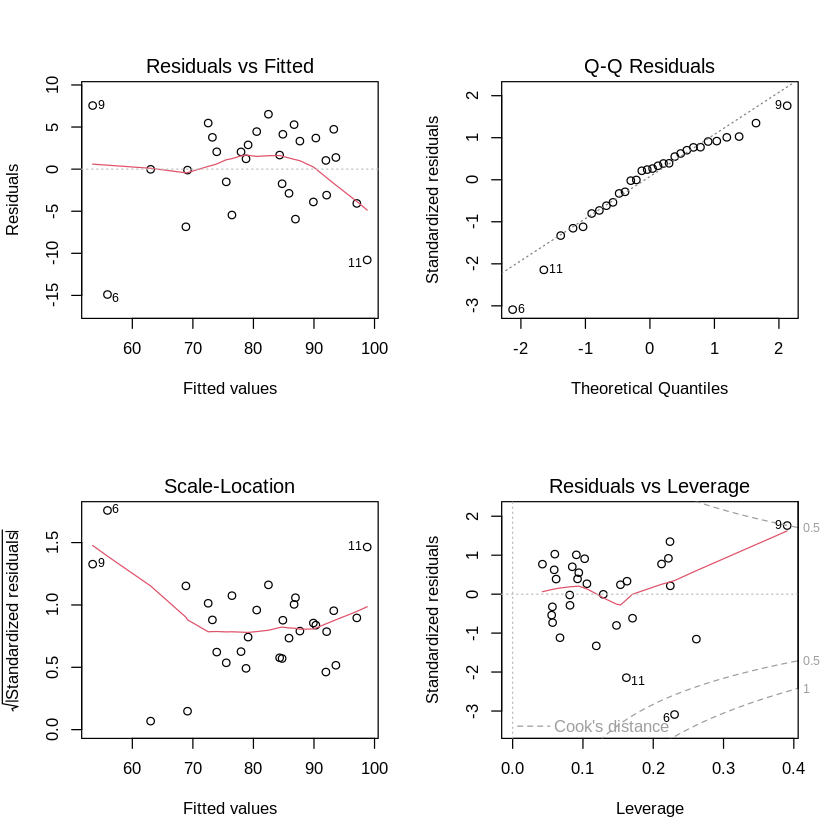

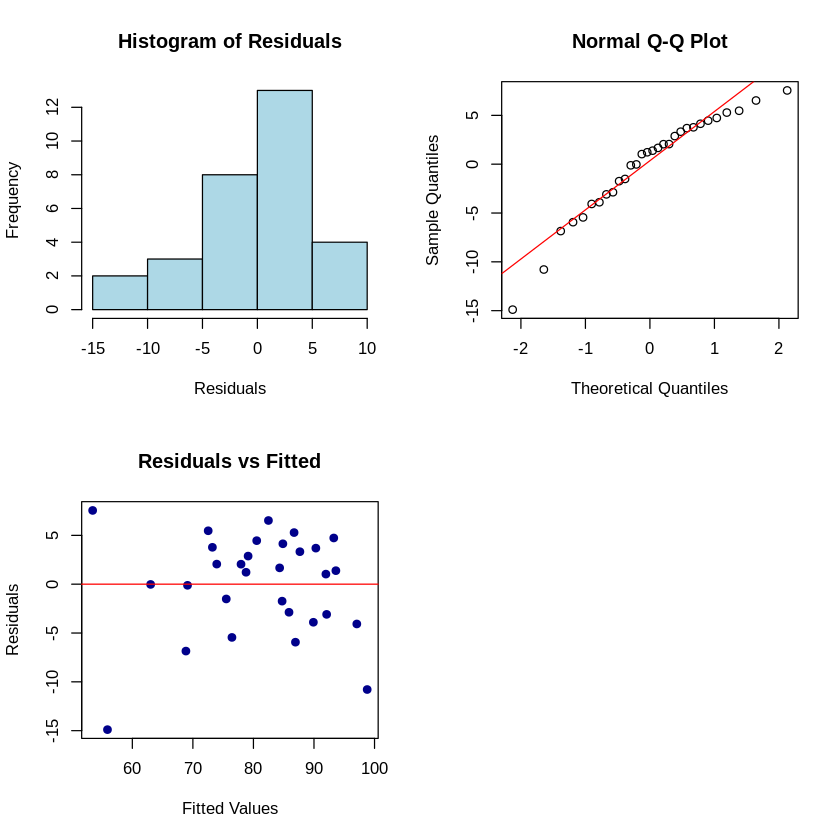

In [ ]:
# Question 5:

# Extracting residuals and fitted values
res <- residuals(model1)
fit <- fitted(model1)

# Step 1. Checking whether E[e] ≈ 0
mean(res)

# Step 2. Residual plots (these are the basic diagnostic plots)
par(mfrow = c(2,2))
plot(model1)

# Step 3. Histogram of residuals
hist(res,
     main = "Histogram of Residuals",
     xlab = "Residuals",
     col = "lightblue",
     border = "black")

# Step 4. Normal Q-Q plot
qqnorm(res)
qqline(res, col="red")

# Step 5. Shapiro-Wilk test for normality
shapiro.test(res)

# Step 6. Residuals vs Fitted (variance check)
plot(fit, res,
     main = "Residuals vs Fitted",
     xlab = "Fitted Values",
     ylab = "Residuals",
     pch = 19,
     col = "darkblue")
abline(h = 0, col = "red")

To evaluate the random error assumptions for the first-order regression model, I examined whether the residuals satisfy the conditions (E[ε] = 0), normality, and constant variance.

First, I checked whether the mean of the residuals is approximately zero. The computed mean of the residuals is **1.66 × 10⁻¹⁶**, honestly, which is essentially zero. This indicates that the assumption (E[ε] = 0) is satisfied.

Next, I assessed the **normality of the residuals** using both graphical methods and a formal statistical test. From the **histogram of residuals**, the distribution appears roughly symmetric and bell-shaped. The **Normal Q-Q plot** also shows that most points lie close to the reference line, with only small deviations at the tails. In addition, the **Shapiro–Wilk test** produced a **p-value of approximately 0.0526**. Since this value is slightly greater than 0.05, I do not reject the null hypothesis of normality. Therefore, the residuals appear to be **reasonably consistent with the normality assumption**.

Finally, I examined the **constant variance (homoscedasticity) assumption** using the **Residuals vs Fitted** and **Scale-Location** plots. In my observation, the residuals appear to be randomly scattered around zero without a strong funnel pattern, suggesting that the variance of the errors is roughly constant across the range of fitted values. While there may be slight variation in spread, there is no clear systematic pattern that would indicate serious heteroscedasticity...

Overall, based on these diagnostic checks, I will say **the key random error assumptions for the first-order regression model appear to be reasonably satisfied**. The residuals have mean approximately zero, follow an approximately normal distribution, and show no strong evidence of non-constant variance. Therefore, the first-order regression model appears appropriate for further analysis...

#**Question 6**

In [ ]:
# Question 6

# Given are the predictor values, so let's assign those values
new_team <- data.frame(
  BA = 0.250,
  ERA = 4.00,
  SB = 120
)

# (a) 95% confidence interval for the mean number of wins
predict(model1,
        newdata = new_team,
        interval = "confidence",
        level = 0.95)

# (b) 95% prediction interval for a single future observation
predict(model1,
        newdata = new_team,
        interval = "prediction",
        level = 0.95)

,fit,lwr,upr
1,86.50884,84.06284,88.95485


,fit,lwr,upr
1,86.50884,74.95317,98.06451


For this Question 6, I used the fitted first-order regression model to estimate the expected number of wins when **BA = 0.250**, **ERA = 4.00**, and **SB = 120**.

First, in (a), I computed the **95% confidence interval for the mean number of wins** for teams with these predictor values. The model estimates the expected number of wins to be **86.51**. The **95% confidence interval** for the mean number of wins is **(84.06, 88.95)**. This means that I am **95% confident that the true mean number of wins for teams with BA = 0.250, ERA = 4.00, and SB = 120 lies between approximately 84.06 and 88.95 wins**.

Next, in (b), I computed the **95% prediction interval for a single future observation**. The **95% prediction interval** is **(74.95, 98.06)**. This interval is wider than the confidence interval because it accounts not only for the uncertainty in estimating the mean response, but also for the variability of individual observations around that mean.

Therefore, in my observation, while the **expected number of wins is about 86.51**, an individual team with **BA = 0.250, ERA = 4.00, and SB = 120** could reasonably have between **about 74.95 and 98.06 wins**, according to the model...

#**Question 7**

1           2           3           4           5           6 
 1.34759293 -0.61766427  0.62425161 -1.11933492 -0.53849892 -3.09017776 
          7           8           9          10          11          12 
 0.77430212  1.00875877  1.76086687  0.33219788 -2.14436561 -0.73076903 
         13          14          15          16          17          18 
-0.00465462  0.90913959 -1.32829933  0.21333016  0.55048375  0.76974309 
         19          20          21          22          23          24 
 0.70239721 -0.02186505  0.26642391  0.38668174 -0.80306334  0.91960564 
         25          26          27          28          29          30 
 0.39125358 -0.32539088  0.24153533  1.02704283 -0.28718632 -1.15434159

6 11 
 6 11

1            2            3            4            5            6 
1.309265e-01 1.960880e-02 6.118389e-03 2.261257e-02 4.259505e-03 7.143986e-01 
           7            8            9           10           11           12 
4.028413e-02 2.535255e-02 4.967465e-01 5.360605e-03 2.218658e-01 8.046596e-03 
          13           14           15           16           17           18 
8.022443e-07 2.357529e-02 5.955610e-02 3.289576e-03 7.867493e-03 6.553497e-03 
          19           20           21           22           23           24 
1.143081e-02 1.056508e-05 2.095524e-03 2.464114e-03 2.793916e-02 6.018738e-02 
          25           26           27           28           29           30 
3.892525e-03 1.587223e-03 2.642213e-03 1.682951e-02 1.831532e-03 1.178599e-01

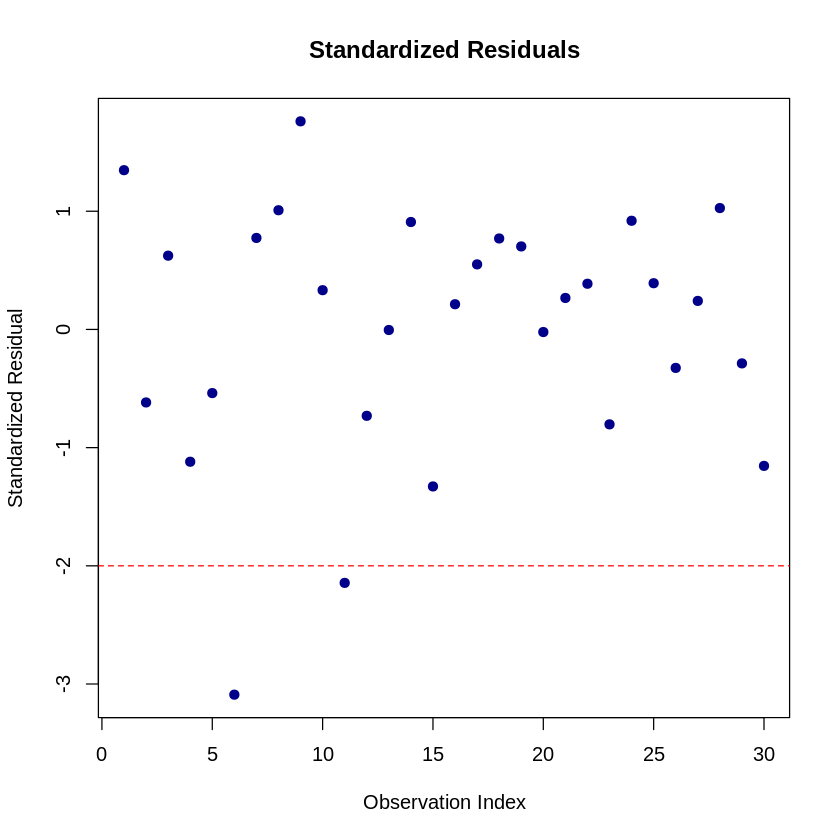

6  9 11 
 6  9 11

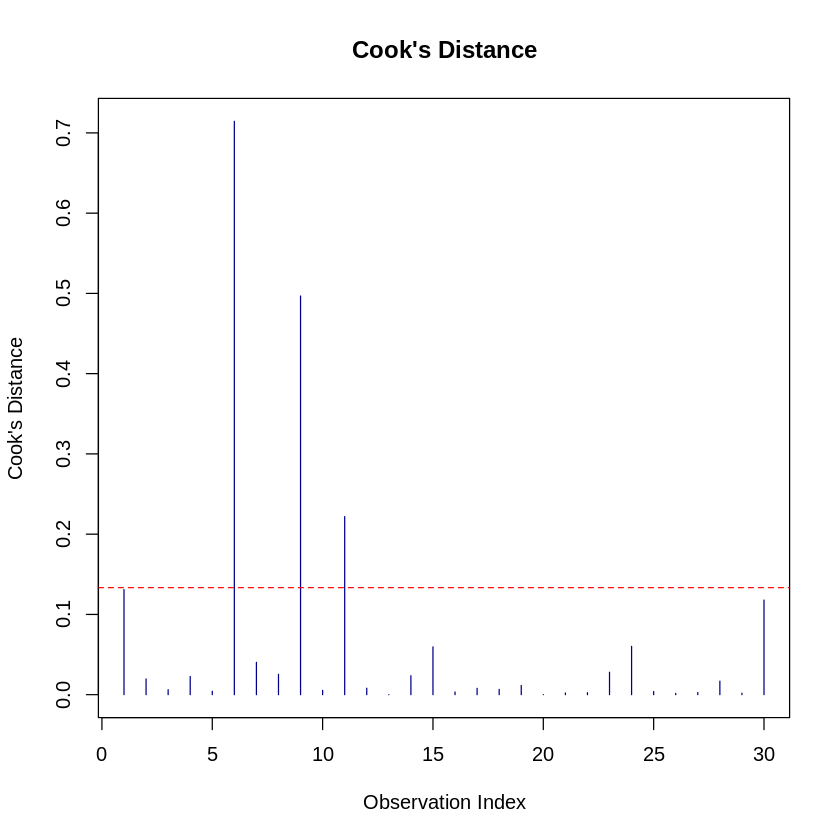

In [ ]:
# Question 7:

# Standardized residuals
std_res <- rstandard(model1)

# Printing standardized residuals
std_res

# Identifying potential outliers (|standardized residual| > 2)
which(abs(std_res) > 2)

# Plotting standardized residuals
plot(std_res,
     main = "Standardized Residuals",
     ylab = "Standardized Residual",
     xlab = "Observation Index",
     pch = 19,
     col = "darkblue")
abline(h = c(-2, 2), col = "red", lty = 2)

# Cook's Distance
cook <- cooks.distance(model1)

# Printing Cook's distance
cook

# Plotting Cook's distance
plot(cook,
     type = "h",
     main = "Cook's Distance",
     ylab = "Cook's Distance",
     xlab = "Observation Index",
     col = "darkblue")

# Let's reference threshold for influential observations
abline(h = 4/length(cook), col = "red", lty = 2)

# Identifying observations with large Cook's distance
which(cook > (4/length(cook)))

To determine whether there are any outliers or influential observations in the first-order regression model, I examined the **standardized residuals** and **Cook’s distance**.

First, I looked at the **standardized residuals**. A common guideline is that observations with standardized residuals larger than about **(-/+ 2)** may indicate potential outliers. From the results and the standardized residual plot, I observe that **observation 6 and observation 9** have standardized residuals with magnitude greater than 2. This suggests that these two observations may be considered **potential outliers in terms of their residual values**, meaning the model does not fit those observations as well as the others.

Next, I examined **Cook’s distance**, which measures the influence of each observation on the fitted regression model. A commonly used threshold is **4/n**, where (n) is the number of observations. Since there are **30 teams**, the reference value is approximately **4/30 = 0.133**. From the Cook’s distance plot and the computed values, **observations 6, 9, and 11** appear to exceed this threshold, indicating that these observations may have **relatively large influence on the fitted regression model**.

Overall, based on the standardized residuals and Cook’s distance, I observe that **observations 6 and 9 may be potential outliers**, and **observations 6, 9, and 11 may be influential points** in the regression analysis. However, these observations do not necessarily need to be removed, but they should be examined more carefully to determine whether they represent unusual teams or influential data points affecting the model fit...

#**Question 8**

In [ ]:
# Question 8:

# Fitting the enhanced model
model2 <- lm(W ~ BA + ERA + SB + I(BA^2) + I(ERA^2) + BA:ERA, data = baseball)

# Here is the full regression output
summary(model2)

# ANOVA table for the enhanced model
anova(model2)

# R-squared values
summary(model2)$r.squared
summary(model2)$adj.r.squared

# Coefficients only
coef(model2)


Call:
lm(formula = W ~ BA + ERA + SB + I(BA^2) + I(ERA^2) + BA:ERA, 
    data = baseball)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.3061 -3.3523  0.9591  3.2332  7.0911 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.148e+02  4.171e+02   0.515 0.611527    
BA           1.748e+03  3.060e+03   0.571 0.573301    
ERA         -1.875e+02  4.968e+01  -3.775 0.000981 ***
SB          -3.643e-03  2.019e-02  -0.180 0.858392    
I(BA^2)     -7.603e+03  5.875e+03  -1.294 0.208488    
I(ERA^2)     1.945e+00  3.056e+00   0.637 0.530693    
BA:ERA       6.296e+02  1.974e+02   3.189 0.004080 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.557 on 23 degrees of freedom
Multiple R-squared:  0.8941,	Adjusted R-squared:  0.8664 
F-statistic: 32.35 on 6 and 23 DF,  p-value: 4.223e-10


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
BA,1,1.713348e+03,1.713348e+03,8.249231e+01,4.548473e-09
ERA,1,2.010715e+03,2.010715e+03,9.680959e+01,1.037097e-09
SB,1,1.486154e-02,1.486154e-02,7.155364e-04,9.788903e-01
I(BA^2),1,6.147096e+01,6.147096e+01,2.959633e+00,9.879592e-02
I(ERA^2),1,3.443118e+01,3.443118e+01,1.657753e+00,2.107126e-01
BA:ERA,1,2.112820e+02,2.112820e+02,1.017257e+01,4.080240e-03
Residuals,23,4.777051e+02,2.076979e+01,NA,NA


[1] 0.8940544

[1] 0.8664164

(Intercept)            BA           ERA            SB       I(BA^2) 
 2.147511e+02  1.748338e+03 -1.875431e+02 -3.643193e-03 -7.602821e+03 
     I(ERA^2)        BA:ERA 
 1.945327e+00  6.295824e+02

For Question 8, I fit the enhanced second-order regression model

y = β₀ + β₁BA + β₂ERA + β₃SB + β₄(BA^2) + β₅(ERA^2) + β₆(BA·ERA) + ε

to examine whether adding quadratic and interaction terms improves the explanation of wins.

To determine which predictors are significant, I examined the **p-values of the regression coefficients**. From the regression output, **ERA is statistically significant** with a p-value of approximately **0.00098**, indicating that ERA continues to be an important predictor of the number of wins. In addition, the **interaction term BA × ERA is also statistically significant** with a p-value of about **0.00408**, suggesting that the effect of batting average on wins may depend on the level of ERA (or vice versa).

On the other hand, **BA, SB, (BA^2), and (ERA^2) are not statistically significant** at the 5% significance level because their p-values are greater than 0.05. This suggests that, after accounting for ERA and the interaction between BA and ERA, these terms do not provide strong additional explanatory power for predicting wins in this model.

Overall, based on the p-values, **ERA and the interaction term BA × ERA are the significant predictors in the enhanced second-order model**, while **BA, SB, (BA^2), and (ERA^2) are not statistically significant** at the 5% level...

#**Question 9**

In [ ]:
# Question 9:
# Partial F-test to compare reduced vs enhanced model

# Reduced model (from Question 4)
model1 <- lm(W ~ BA + ERA + SB, data = baseball)

# Enhanced model (from Question 8)
model2 <- lm(W ~ BA + ERA + SB + I(BA^2) + I(ERA^2) + BA:ERA, data = baseball)

# Partial F-test comparing the two models
anova(model1, model2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,26,784.8893,NA,NA,NA,NA
2,23,477.7051,3,307.1842,4.929984,0.008666381


To determine whether the enhanced second-order model provides a better fit than the first-order (reduced) model, I performed a **partial F-test** comparing the two models. The reduced model includes the predictors **BA, ERA, and SB**, while the enhanced model additionally includes **(BA^2), (ERA^2), and the interaction term BA × ERA**.

From the ANOVA comparison, the test statistic is **F = 4.929984** with a **p-value ≈ 0.00867**. The null hypothesis for this test is that the additional terms in the enhanced model (BA^2, ERA^2, and BA × ERA) do not improve the model, meaning their coefficients are all equal to zero.

Since the **p-value is less than 0.05**, I reject the null hypothesis. This indicates that the additional second-order and interaction terms **significantly improve the model fit** compared to the first-order model.

Therefore, based on the partial F-test, **the enhanced second-order model provides a statistically better fit to the data than the first-order model**...


#**Question 10**

In [ ]:
# Question 10:
# Effect of a 0.010 increase in BA using the enhanced model (others kept constant)

# Current values
team1 <- data.frame(
  BA = 0.250,
  ERA = 4.00,
  SB = 120
)

# BA increased by 0.010
team2 <- data.frame(
  BA = 0.260,
  ERA = 4.00,
  SB = 120
)

# Predicted wins for both cases
pred1 <- predict(model2, newdata = team1)
pred2 <- predict(model2, newdata = team2)

# Effect of the increase in BA
effect <- pred2 - pred1

pred1
pred2
effect

1 
86.75746

1 
90.64976

1 
3.892291

To determine the effect of a **0.010 increase in BA** on the expected number of wins, I used the enhanced second-order regression model while holding **ERA = 4.00** and **SB = 120** constant.

First, I computed the predicted number of wins when **BA = 0.250**, **ERA = 4.00**, and **SB = 120**. The model predicts approximately **86.76 wins**. Next, I increased BA by **0.010**, setting **BA = 0.260** while keeping ERA and SB fixed at the same values (i.e., constant). Under these conditions, the predicted number of wins increases to approximately **90.65 wins**.

The effect of the 0.010 increase in BA is therefore the difference between these two predicted values:

**90.65 − 86.76 = 3.89 wins**.

Thus, according to the enhanced model, **increasing BA by 0.010 (while holding ERA = 4.00 and SB = 120 constant) increases the expected number of wins by approximately 3.89 games**...

#**Question 11**

[1] 2.217555e-17


	Shapiro-Wilk normality test

data:  res2
W = 0.96344, p-value = 0.3781


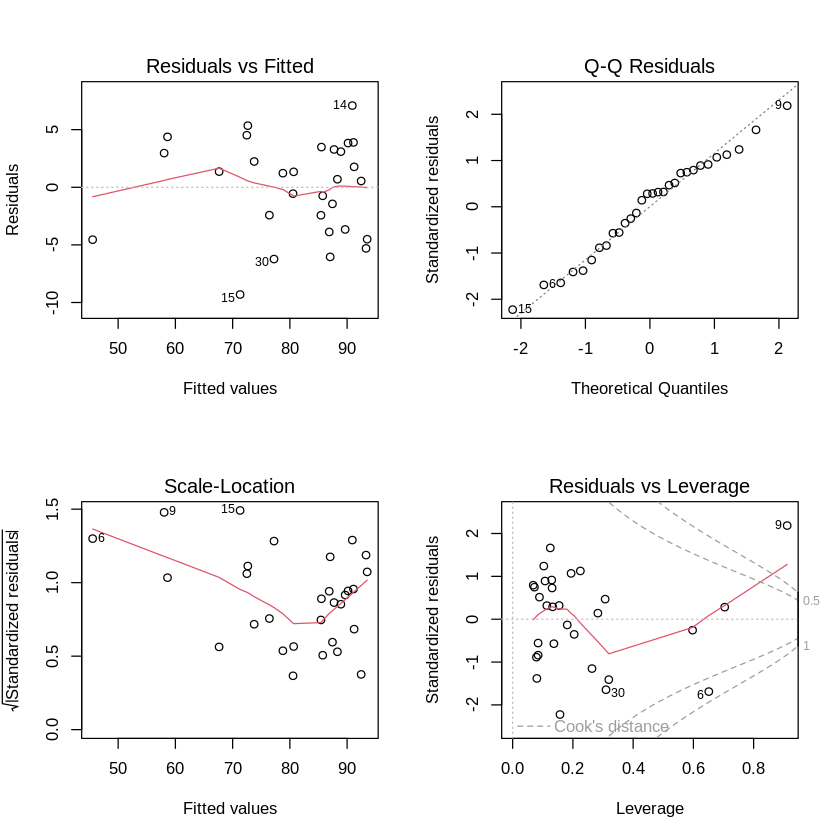

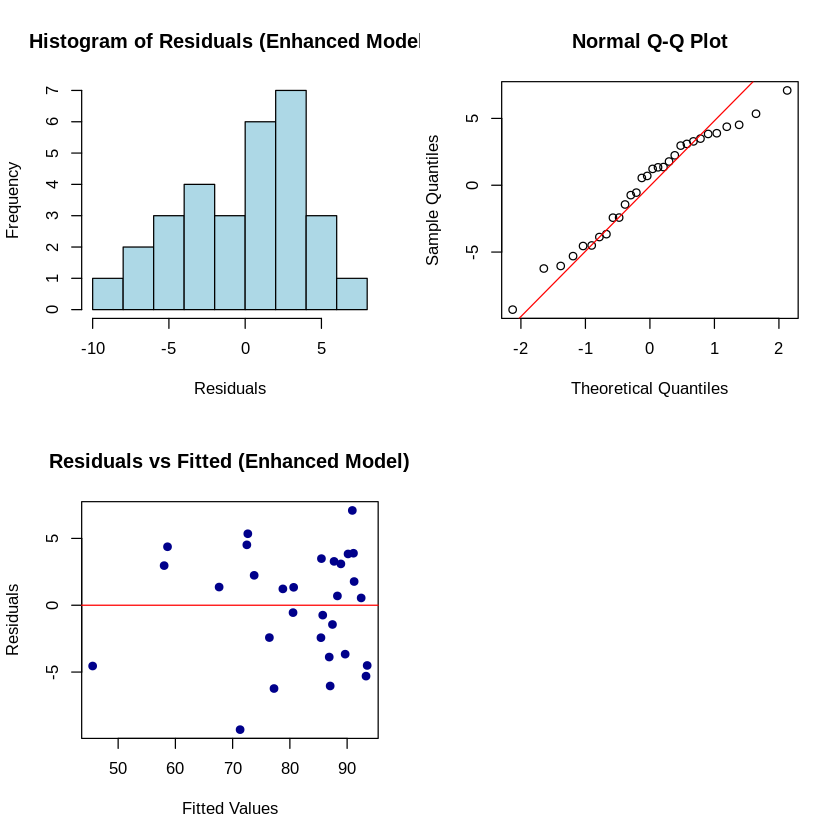

In [ ]:
# Question 11

# Extracting residuals and fitted values
res2 <- residuals(model2)
fit2 <- fitted(model2)

# Step 1. Checking whether E[e] ≈ 0
mean(res2)

# Step 2. Standard diagnostic plots
par(mfrow = c(2,2))
plot(model2)

# Step 3. Histogram of residuals
hist(res2,
     main = "Histogram of Residuals (Enhanced Model)",
     xlab = "Residuals",
     col = "lightblue",
     border = "black")

# Step 4. Normal Q-Q plot
qqnorm(res2)
qqline(res2, col = "red")

# Step 5. Shapiro-Wilk test for normality
shapiro.test(res2)

# Step 6. Residuals vs Fitted plot
plot(fit2, res2,
     main = "Residuals vs Fitted (Enhanced Model)",
     xlab = "Fitted Values",
     ylab = "Residuals",
     pch = 19,
     col = "darkblue")
abline(h = 0, col = "red")

To evaluate the random error assumptions for the **enhanced (second-order) regression model**, I examined whether the residuals satisfy the conditions (E[ε] = 0), normality, and constant variance.

First, I checked whether the mean of the residuals is approximately zero. The computed mean of the residuals is **2.22 × 10^(-17)**, which is essentially zero. This indicates that the assumption (E[ε] = 0) is satisfied for the enhanced model.

Next, I evaluated the **normality of the residuals** using both graphical methods and the **Shapiro–Wilk test**. From the **histogram of residuals**, the distribution appears roughly symmetric and approximately bell-shaped. The **Normal Q-Q plot** also shows that most of the points lie close to the reference line with only minor deviations at the tails. In addition, the **Shapiro–Wilk test** produced a **p-value of approximately 0.378**, which is much greater than 0.05. Therefore, I do not reject the null hypothesis of normality, indicating that the residuals appear to follow a normal distribution.

Finally, I examined the **constant variance (homoscedasticity) assumption** using the **Residuals vs Fitted** and **Scale-Location** plots. In my observation, the residuals appear to be randomly scattered around zero without a clear funnel-shaped pattern, suggesting that the variance of the residuals remains approximately constant across the range of fitted values.

Overall, based on these diagnostic checks, **the key random error assumptions for the enhanced regression model appear to be reasonably satisfied**. The residuals have mean approximately zero, follow an approximately normal distribution, and show no strong evidence of non-constant variance, indicating that the enhanced model is appropriate for inference...

#**HTML Download**

In [ ]:
import nbformat
from nbconvert import HTMLExporter
import os
from google.colab import files

# 1. Path to my notebook
input_path = "/content/drive/MyDrive/Colab Notebooks/Homework_5_AnayJoshi.ipynb"
output_html = "Homework_5_AnayAbhijitJoshi.html"

# 2. Loading the notebook
with open(input_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

for cell in nb.cells:
    if 'metadata' in cell:
        if 'widgets' in cell.metadata:
            del cell.metadata['widgets']

# 4. Configuring the HTML Exporter to be as simple as possible
html_exporter = HTMLExporter()
html_exporter.template_name = 'lab'

# 5. Converting now
(body, resources) = html_exporter.from_notebook_node(nb)

# 6. Saving and Downloading
with open(output_html, 'w', encoding='utf-8') as f:
    f.write(body)

if os.path.exists(output_html):
    files.download(output_html)
    print("Success! Clean HTML generated and download triggered.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! Clean HTML generated and download triggered.
